
# # 📚 RAG-System mit LangChain, ChromaDB und Gemini 2
# Dieses Notebook implementiert ein einfaches Retrieval-Augmented Generation (RAG) System.
# Es verwendet ChromaDB zur Dokumentenspeicherung, LangChain für Workflow-Management und das Modell `gemini-2.0-flash`.


# 📥 Bibliotheken importieren

In [ ]:
from langchain_community.document_loaders import WebBaseLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

from langchain.vectorstores import Chroma
from langchain.memory import ConversationBufferMemory
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.chains import ConversationalRetrievalChain

import os

from langchain_community.embeddings import HuggingFaceEmbeddings


USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
os.environ["USER_AGENT"] = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36"

# ## 🌐 Schritt 1: Wikipedia-Seite laden

In [5]:
url = "https://en.wikipedia.org/wiki/2025_in_science"
loader = WebBaseLoader(url)
documents = loader.load()

# ## ✂️ Schritt 2: Text in Chunks aufteilen

In [6]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)
chunks = splitter.split_documents(documents)
print(f"Anzahl der Chunks: {len(chunks)}")

Anzahl der Chunks: 90


# ## 🧠 Schritt 3: Vektorisierung und Speicherung in ChromaDB

embedding

In [8]:
embedding = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")

C:\Users\volodymyr\AppData\Local\Temp\ipykernel_14700\4093584008.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")
c:\Users\volodymyr\AppData\Local\anaconda3\envs\rag_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


chromaDB

In [ ]:


persist_directory = "chroma_db"
if os.path.exists(persist_directory) and os.listdir(persist_directory):
    vectorstore = Chroma(persist_directory=persist_directory, embedding_function=embedding)
else:
    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embedding,
        persist_directory=persist_directory
    )
    vectorstore.persist()


C:\Users\volodymyr\AppData\Local\Temp\ipykernel_14700\2098072650.py:6: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectorstore = Chroma(persist_directory=persist_directory, embedding_function=embedding)


langsmith

In [ ]:
os.environ["LANGCHAIN_PROJECT"] = "RAG Wikipedia 2025"
os.environ["LANGCHAIN_TRACING_V2"] = "true"
from langchain.callbacks.tracers import LangChainTracer

tracer = LangChainTracer(project_name="RAG Wikipedia 2025")


class State erstellen

In [11]:
from langchain_core.documents import Document
from typing_extensions import List, TypedDict


class State(TypedDict):
    question: str
    context: List[Document]
    answer: str


# ## 💬 Schritt 4: Dialogsystem mit Gedächtnis (Memory)

## 💾 Kontextverwaltung über mehrere Sitzungen
Wir verwenden `FileChatMessageHistory`, um den Gesprächsverlauf zwischen Sitzungen zu speichern.
Dies ermöglicht eine langfristige Konversationshistorie.

In [12]:
from langchain.memory.chat_message_histories import FileChatMessageHistory
from langchain.retrievers.multi_query import MultiQueryRetriever
message_history = FileChatMessageHistory("chat_history.json")

memory = ConversationBufferMemory(
    memory_key="chat_history",
    chat_memory=message_history,
    return_messages=True
)






llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")



C:\Users\volodymyr\AppData\Local\Temp\ipykernel_14700\112953629.py:5: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationBufferMemory(


Prompt erstellen

In [13]:
from langchain import hub

prompt = hub.pull("rlm/rag-prompt")

example_messages = prompt.invoke(
    {"context": "(context goes here)", "question": "(question goes here)"}
).to_messages()

assert len(example_messages) == 1
print(example_messages[0].content)

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: (question goes here) 
Context: (context goes here) 
Answer:


Finktionen retrieve und generate

In [14]:

def retrieve(state: State):
    retrieved_docs = vectorstore.similarity_search(state["question"])
    return {"context": retrieved_docs}




def generate(state: State):
    #  Lade bisherigen Gesprächsverlauf aus der Datei
    history = memory.load_memory_variables({})["chat_history"]
    custom_instruction = "Antworte auf Deutsch unbedingt."

    #  Bereite die Dokumente für den Prompt vor
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    print(state['context'])

    #  Kombiniere Kontext + Chatverlauf im Prompt
    full_context = f"{custom_instruction}\n\n{history}\n\nDokumente:\n{docs_content}"
    
    #  Erzeuge Prompt mit LangChain Hub-Vorlage
    messages = prompt.invoke({
        "question": state["question"],
        "context": full_context
    })

    #  LLM generiert eine Antwort
    response = llm.invoke(messages, config={"callbacks": [tracer]})

    #  Speichere aktuelle Frage und Antwort im Speicher (für nächste Runde)
    memory.save_context(
        inputs={"input": state["question"]},
        outputs={"output": response.content}
    )

    #  Rückgabe für das nächste Graph-State
    return {"answer": response.content}

Graph

In [15]:
from langgraph.graph import START, StateGraph

graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

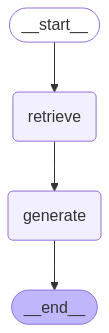

In [16]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

Test

In [17]:


result = graph.invoke({"question": "What is the total number of confirmed satellites of Saturn currently known?"})

print(f'Context: {result["context"]}\n\n')
print(f'Answer: {result["answer"]}')

[Document(metadata={'language': 'en', 'title': '2025 in science - Wikipedia', 'source': 'https://en.wikipedia.org/wiki/2025_in_science'}, page_content="11 March\nThe discovery of 128 new moons of Saturn is reported, by astronomers using the Canada–France–Hawaii Telescope, bringing the gas giant's total number of confirmed satellites to 274.[57][58]"), Document(metadata={'source': 'https://en.wikipedia.org/wiki/2025_in_science', 'title': '2025 in science - Wikipedia', 'language': 'en'}, page_content='^ "2025 Discovery of more Saturnian Moons". The University of British Columbia. The University of British Columbia. 11 March 2025. Retrieved 12 March 2025.\n\n^ "Saturn has 128 new moons – more than the rest of the planets combined". New Scientist. New Scientist. 11 March 2025. Retrieved 12 March 2025.\n\n^ "Planetary System Found Around Nearest Single Star". NOIRLab. NOIRLab. 11 March 2025. Retrieved 15 March 2025.'), Document(metadata={'source': 'https://en.wikipedia.org/wiki/2025_in_scie

# ## 🧪 Schritt 5: Beispiel-Dialog

In [18]:

fragen = [
    "When did the second Trump administration impose an immediate freeze on research grants, communications, hiring, and meetings at the National Institutes of Health?",
    "How much of the institute's operations were affected by this decision?",
    "When did astronomers report the discovery of Saturn's new moons?",
    "Which countries' telescopes were used? How many new moons of Saturn were discovered?",
    "What is the total number of confirmed satellites of Saturn currently known?" 
]



In [19]:
for frage in fragen:
    
    result = graph.invoke({"question": frage})
    print(f'Frage: {frage}')
    print(f'Context: {result["context"]}')
    print(f'Antwort: {result["answer"]}\n\n')

[Document(metadata={'language': 'en', 'source': 'https://en.wikipedia.org/wiki/2025_in_science', 'title': '2025 in science - Wikipedia'}, page_content='The exoplanet WASP-127b is discovered to have wind speeds of up to 33,000 km/h, the fastest jetstream of its kind ever measured.[20]\n22 January – The second Trump administration imposes an immediate freeze on scientific grants, communications, hiring, and meetings at the National Institutes of Health (NIH) – by far the biggest supporter of biomedical research worldwide – impacting $47.4 billion worth of activities.[21]\n23 January'), Document(metadata={'source': 'https://en.wikipedia.org/wiki/2025_in_science', 'language': 'en', 'title': '2025 in science - Wikipedia'}, page_content='^ "Trump hits NIH with \'devastating\' freezes on meetings, travel, communications, and hiring". Science. 22 January 2025. Retrieved 24 January 2025.\n\n^ "Strong as steel, light as foam: Machine learning and nano-3D printing create breakthrough nano-archite